# Anomaly Detection on Pump Sensor Data
Unsupervised anomaly detection on multivariate time-series sensor data from an industrial pump.
Two approaches: Isolation Forest (classical) and LSTM Autoencoder (deep learning).
Dataset: Pump Sensor Data (Kaggle) — 52 sensors, ~220,000 timesteps.

**Note:** This notebook runs on Google Colab. Data is stored in temporary session storage
and must be re-downloaded at the start of each session. Run the Kaggle credentials
and data download cells before proceeding.

In [4]:
import os
import json
from getpass import getpass

os.makedirs(os.path.expanduser("~/.config/kaggle"), exist_ok=True)

username = input("Kaggle username: ")
key = getpass("Kaggle API token: ")

kaggle_config = {"username": username, "key": key}

with open(os.path.expanduser("~/.config/kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_config, f)

os.chmod(os.path.expanduser("~/.config/kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured.")

Kaggle username: darrencameron
Kaggle API token: ··········
Kaggle credentials configured.


In [5]:
# Download data
os.makedirs("data/raw", exist_ok=True)
!pip install -q kaggle
!kaggle datasets download -d nphantawee/pump-sensor-data
!unzip -q pump-sensor-data.zip -d data/raw/
!ls data/raw/

Dataset URL: https://www.kaggle.com/datasets/nphantawee/pump-sensor-data
License(s): unknown
100% 37.1M/37.1M [00:00<00:00, 173MB/s] 

sensor.csv


## Imports

In [6]:
import os
import json
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

numpy: 2.0.2
pandas: 2.2.2
torch: 2.10.0+cu128


## Load Data and Exploration

In [7]:
df = pd.read_csv("data/raw/sensor.csv")
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(220320, 55)
   Unnamed: 0            timestamp  sensor_00  sensor_01  sensor_02  \
0           0  2018-04-01 00:00:00   2.465394   47.09201    53.2118   
1           1  2018-04-01 00:01:00   2.465394   47.09201    53.2118   
2           2  2018-04-01 00:02:00   2.444734   47.35243    53.2118   
3           3  2018-04-01 00:03:00   2.460474   47.09201    53.1684   
4           4  2018-04-01 00:04:00   2.445718   47.13541    53.2118   

   sensor_03  sensor_04  sensor_05  sensor_06  sensor_07  ...  sensor_43  \
0  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
1  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
2  46.397570   638.8889   73.54598   13.32465   16.03733  ...   41.66666   
3  46.397568   628.1250   76.98898   13.31742   16.24711  ...   40.88541   
4  46.397568   636.4583   76.58897   13.35359   16.21094  ...   41.40625   

   sensor_44  sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  \
0  39.641200   65.68287   50.925

In [8]:
print(df["machine_status"].value_counts())
print(f"\nTotal rows: {len(df)}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Total rows: 220320

Date range: 2018-04-01 00:00:00 to 2018-08-31 23:59:00


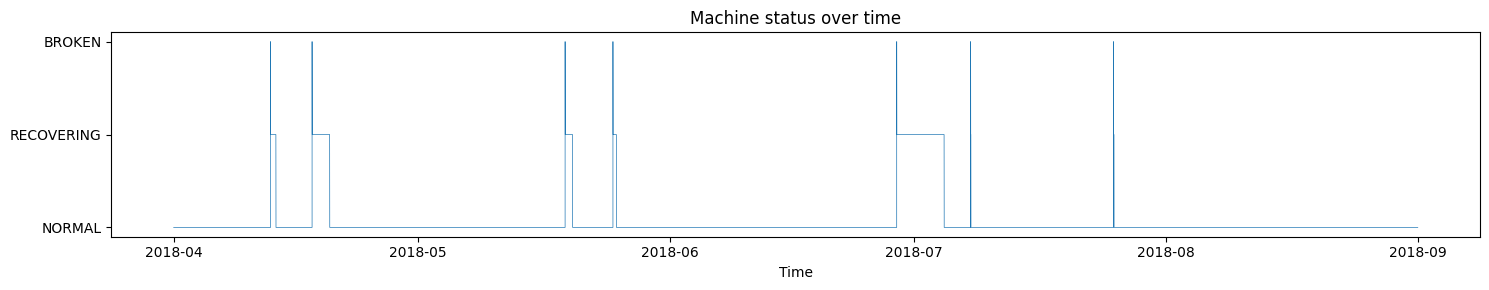

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Plot machine status over time
status_map = {"NORMAL": 0, "RECOVERING": 1, "BROKEN": 2}
df["status_code"] = df["machine_status"].map(status_map)

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df["timestamp"], df["status_code"], linewidth=0.5)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
ax.set_xlabel("Time")
ax.set_title("Machine status over time")
plt.tight_layout()
plt.savefig("data/machine_status.png", dpi=150, bbox_inches="tight")
plt.show()

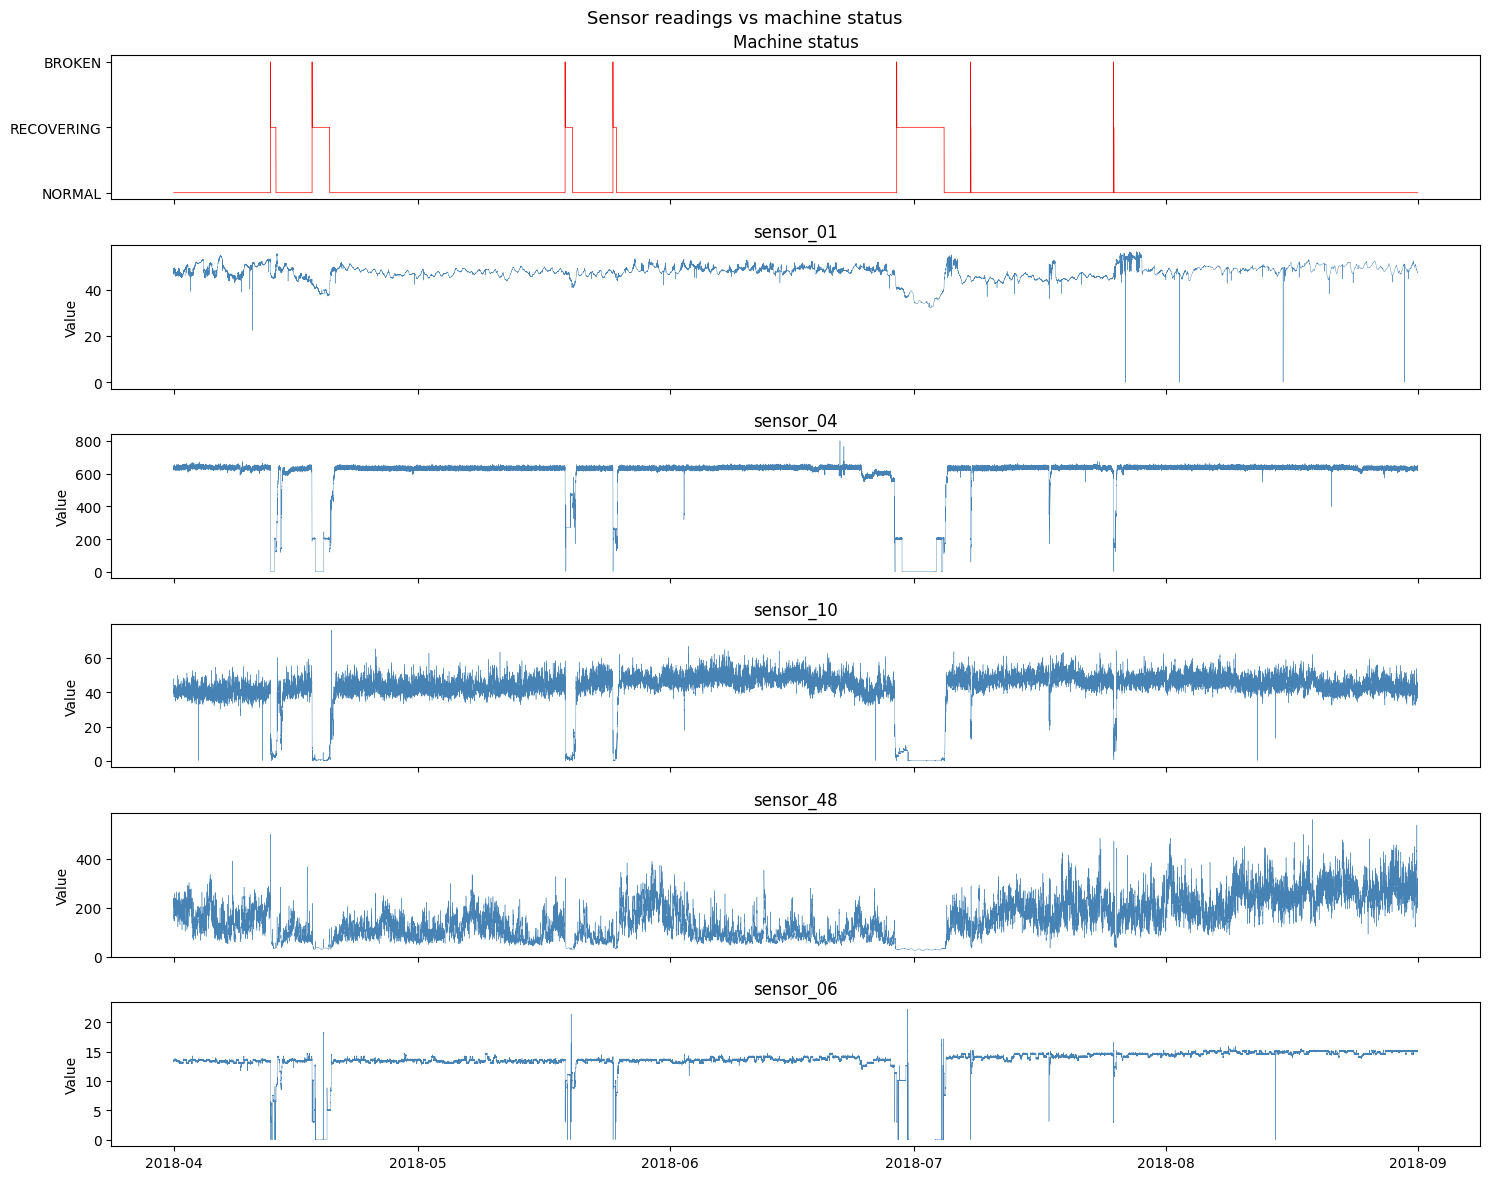

In [10]:
fig, axes = plt.subplots(6, 1, figsize=(15, 12), sharex=True)

# Machine status
axes[0].plot(df["timestamp"], df["status_code"], linewidth=0.5, color="red")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
axes[0].set_title("Machine status")

# A few representative sensors
for ax, sensor in zip(axes[1:], ["sensor_01", "sensor_04", "sensor_10",
                                 "sensor_48", "sensor_06"]):
    ax.plot(df["timestamp"], df[sensor], linewidth=0.3, color="steelblue")
    ax.set_title(sensor)
    ax.set_ylabel("Value")

plt.suptitle("Sensor readings vs machine status", fontsize=13)
plt.tight_layout()
plt.savefig("data/sensor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Look at the BROKEN timesteps in detail
broken = df[df["machine_status"] == "BROKEN"][["timestamp", "machine_status"]]
print(broken)

# Check the timesteps immediately before and after each BROKEN point
for idx in broken.index:
    window = df.loc[max(0, idx-3):idx+3, ["timestamp", "machine_status"]]
    print(window)
    print()

                 timestamp machine_status
17155  2018-04-12 21:55:00         BROKEN
24510  2018-04-18 00:30:00         BROKEN
69318  2018-05-19 03:18:00         BROKEN
77790  2018-05-25 00:30:00         BROKEN
128040 2018-06-28 22:00:00         BROKEN
141131 2018-07-08 00:11:00         BROKEN
166440 2018-07-25 14:00:00         BROKEN
                timestamp machine_status
17152 2018-04-12 21:52:00         NORMAL
17153 2018-04-12 21:53:00         NORMAL
17154 2018-04-12 21:54:00         NORMAL
17155 2018-04-12 21:55:00         BROKEN
17156 2018-04-12 21:56:00     RECOVERING
17157 2018-04-12 21:57:00     RECOVERING
17158 2018-04-12 21:58:00     RECOVERING

                timestamp machine_status
24507 2018-04-18 00:27:00         NORMAL
24508 2018-04-18 00:28:00         NORMAL
24509 2018-04-18 00:29:00         NORMAL
24510 2018-04-18 00:30:00         BROKEN
24511 2018-04-18 00:31:00     RECOVERING
24512 2018-04-18 00:32:00     RECOVERING
24513 2018-04-18 00:33:00     RECOVERING

      

### Dataset description
- ~5 months of pump operation, April to September 2018, at 1-minute resolution
- 220,320 timesteps, 52 sensors recording continuous operational parameters
- Machine status has three states: NORMAL (205,836), RECOVERING (14,477), BROKEN (7)
- 5 to 6 distinct fault events visible across the period, each brief but followed by extended recovery periods
- Sensor responses to fault events vary: some sensors (e.g. sensor_04) track fault events closely, others are noisier or less discriminating
- Missing data visible in several sensors (e.g. sensor_06) — apparent as sudden drops, not true zero readings
- sensor_15 is entirely missing and will be dropped; sensor_50 has 35% missingness and will also be dropped

### Notes on machine status
- Only 7 BROKEN timesteps across the entire dataset — each is a single isolated point
- Every BROKEN point follows the pattern: NORMAL → BROKEN (1 min) → RECOVERING
- BROKEN represents the moment of failure, RECOVERING the aftermath
- Two apparent spikes on the status plot with no visible recovery were an artefact of plot resolution
- For modelling: NORMAL = normal class, BROKEN + RECOVERING = anomalous class

## Step 3 - Data Cleaning

In [12]:
# Drop entirely missing or high missingness sensors
df = df.drop(columns=["sensor_15", "sensor_50", "Unnamed: 0"])

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Forward fill remaining missing values
df = df.ffill()

# Verify no missing values remain
print("Remaining missing values:")
print(df.isnull().sum().sum())
print(f"\nShape after cleaning: {df.shape}")

Remaining missing values:
0

Shape after cleaning: (220320, 53)


### Step 3 results
- Dropped sensor_15 (100% missing), sensor_50 (35% missing), and unnamed index column
- Forward filled remaining missing values across all other sensors
- Final shape: 220,320 rows × 53 columns (timestamp, 51 sensors, machine_status)
- No missing values remain

## Step 4 — Feature Engineering

In [13]:
# Binary anomaly label
df["anomaly"] = (df["machine_status"] != "NORMAL").astype(int)
print("Anomaly label distribution:")
print(df["anomaly"].value_counts())

# Select sensor columns
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(f"\nNumber of sensors: {len(sensor_cols)}")

# Scale features
scaler = StandardScaler()
X = df[sensor_cols].values
X_scaled = scaler.fit_transform(X)

# Train on NORMAL only, test on full dataset
normal_mask = df["anomaly"] == 0
X_train = X_scaled[normal_mask]
X_test = X_scaled
y_test = df["anomaly"].values

print(f"\nTrain (normal only): {X_train.shape}")
print(f"Test (full dataset): {X_test.shape}")

Anomaly label distribution:
anomaly
0    205836
1     14484
Name: count, dtype: int64

Number of sensors: 50

Train (normal only): (205836, 50)
Test (full dataset): (220320, 50)


In [14]:
# Check sensor cols
print(sensor_cols)

['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_51']


### Step 4 results
- Binary anomaly label: 205,836 normal (0), 14,484 anomalous (1) (~6.6% anomalous)
- 50 sensor columns selected: sensor_00 to sensor_51 excluding sensor_15 and sensor_50
- Unnamed index column also dropped at cleaning stage (not a sensor)
- Features scaled to zero mean and unit variance using StandardScaler
- Train set: normal timesteps only (205,836 rows)
- Test set: full dataset (220,320 rows)
- Anomaly label used for evaluation only, not during training

## Step 5 — Isolation Forest

In [15]:
from sklearn.ensemble import IsolationForest

# Train on normal data only
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.066,  # approx prop of anomalies in dataset
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)
print("Isolation Forest trained.")

Isolation Forest trained.


In [16]:
# Generate predictions (-1 = anomaly, 1 = normal in sklearn convention)
iso_pred = iso_forest.predict(X_test)

# Convert to binary (0 = normal, 1 = anomaly) to match our labels
iso_pred_binary = (iso_pred == -1).astype(int)

# Anomaly scores (more negative = more anomalous)
iso_scores = iso_forest.decision_function(X_test)

print(classification_report(y_test, iso_pred_binary,
      target_names=["normal", "anomaly"]))

              precision    recall  f1-score   support

      normal       1.00      0.93      0.97    205836
     anomaly       0.51      0.99      0.68     14484

    accuracy                           0.94    220320
   macro avg       0.76      0.96      0.82    220320
weighted avg       0.97      0.94      0.95    220320



### Step 5 results — Isolation Forest
- Anomaly recall: 0.99 — model detects 99% of true fault periods
- Anomaly precision: 0.51 — approximately half of flagged anomalies are true faults
- High recall prioritised over precision — in condition monitoring, missing a fault is more costly than a false alarm
- Overall accuracy 94% — inflated by class imbalance, F1 scores more informative
- Contamination parameter set to known anomaly proportion (0.066) — in practice this would need to be estimated

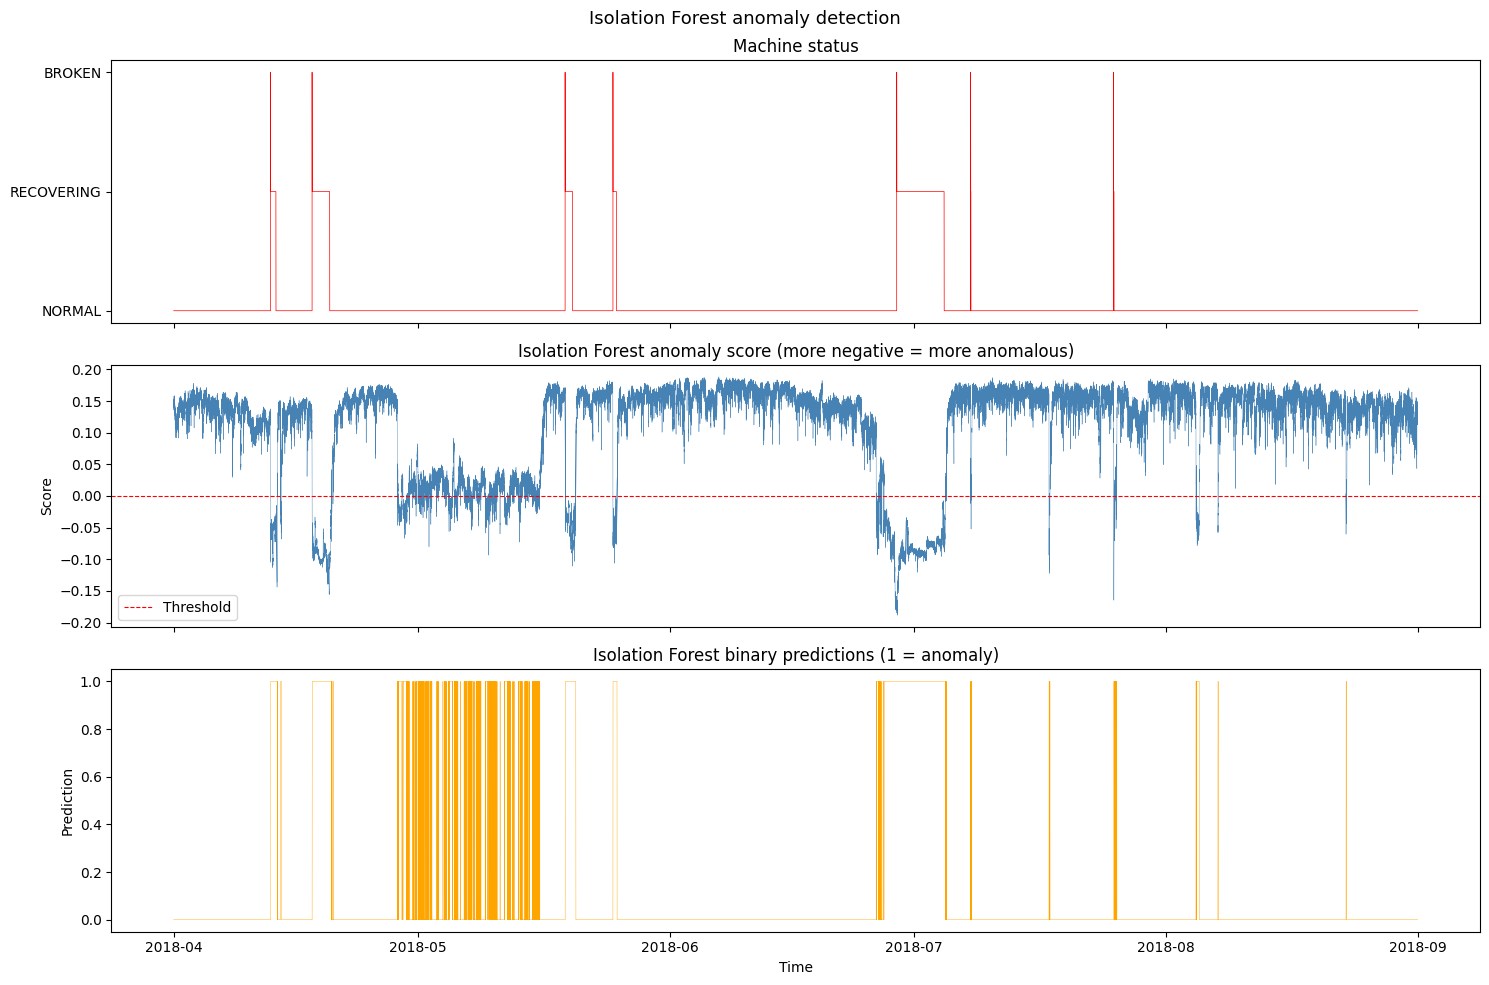

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Machine status
axes[0].plot(df["timestamp"], df["status_code"], linewidth=0.5, color="red")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
axes[0].set_title("Machine status")

# Isolation Forest anomaly score
axes[1].plot(df["timestamp"], iso_scores, linewidth=0.3, color="steelblue")
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=0.8, label="Threshold")
axes[1].set_title("Isolation Forest anomaly score (more negative = more anomalous)")
axes[1].set_ylabel("Score")
axes[1].legend()

# Binary predictions
axes[2].plot(df["timestamp"], iso_pred_binary, linewidth=0.3, color="orange")
axes[2].set_title("Isolation Forest binary predictions (1 = anomaly)")
axes[2].set_ylabel("Prediction")
axes[2].set_xlabel("Time")

plt.suptitle("Isolation Forest anomaly detection", fontsize=13)
plt.tight_layout()
plt.savefig("data/isolation_forest_results.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations
- Anomaly score clearly tracks fault periods — drops below threshold during BROKEN and RECOVERING
- July fault event most severe — largest score drop (~-0.18)
- Binary predictions noisy around May period — score hovering near threshold causes false alarms
- Continuous anomaly score more informative than binary predictions
- Motivates LSTM autoencoder approach — smoother reconstruction error as health score

## Step 6 — LSTM Autoencoder

In [18]:
def create_sequences(data, seq_length=30):
    """Slice time-series data into overlapping sequences."""
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

# Create sequences
seq_length = 30
X_train_seq = create_sequences(X_train, seq_length)
X_test_seq = create_sequences(X_scaled, seq_length)

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Train sequences: (205806, 30, 50)
Test sequences: (220290, 30, 50)


### Model architecture

In [19]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64, n_layers=2):
        super(LSTMAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True
        )

        # Decoder
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=n_features,
            num_layers=n_layers,
            batch_first=True
        )

    def forward(self, x):
        # Encode
        _, (hidden, _) = self.encoder(x)

        # Repeat hidden state across sequence length for decoder input
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, x.shape[1], 1)

        # Decode
        output, _ = self.decoder(decoder_input)
        return output

# Initialise model
n_features = X_train_seq.shape[2]  # 50 sensors
model = LSTMAutoencoder(n_features=n_features, hidden_size=64, n_layers=2)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMAutoencoder(
  (encoder): LSTM(50, 64, num_layers=2, batch_first=True)
  (decoder): LSTM(64, 50, num_layers=2, batch_first=True)
)

Total parameters: 106,576


In [20]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_seq)
X_test_tensor = torch.FloatTensor(X_test_seq)

# DataLoader for batching
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Loss function and optimiser
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Training on: {device}")

Training on: cuda


In [21]:
# Training Loop
n_epochs = 50
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.6f}")

print("\nTraining complete.")

Epoch 5/50 — Loss: 0.261763
Epoch 10/50 — Loss: 0.252573
Epoch 15/50 — Loss: 0.249196
Epoch 20/50 — Loss: 0.247377
Epoch 25/50 — Loss: 0.246309
Epoch 30/50 — Loss: 0.245547
Epoch 35/50 — Loss: 0.244911
Epoch 40/50 — Loss: 0.244502
Epoch 45/50 — Loss: 0.244091
Epoch 50/50 — Loss: 0.243800

Training complete.


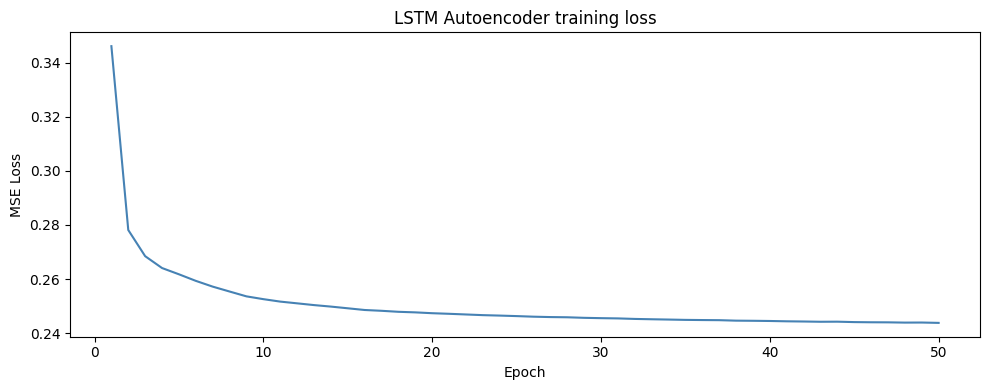

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, n_epochs + 1), train_losses, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder training loss")
plt.tight_layout()
plt.savefig("data/lstm_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

### Reconstruction error and health score

In [23]:
model.eval()
reconstruction_errors = []

with torch.no_grad():
    for i in range(0, len(X_test_tensor), 256):
        batch = X_test_tensor[i:i+256].to(device)
        output = model(batch)
        error = torch.mean((output - batch) ** 2, dim=(1, 2))
        reconstruction_errors.extend(error.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)

print(f"Reconstruction errors shape: {reconstruction_errors.shape}")
print(f"Min: {reconstruction_errors.min():.4f}")
print(f"Max: {reconstruction_errors.max():.4f}")
print(f"Mean: {reconstruction_errors.mean():.4f}")

Reconstruction errors shape: (220290,)
Min: 0.0032
Max: 68.2001
Mean: 0.4124


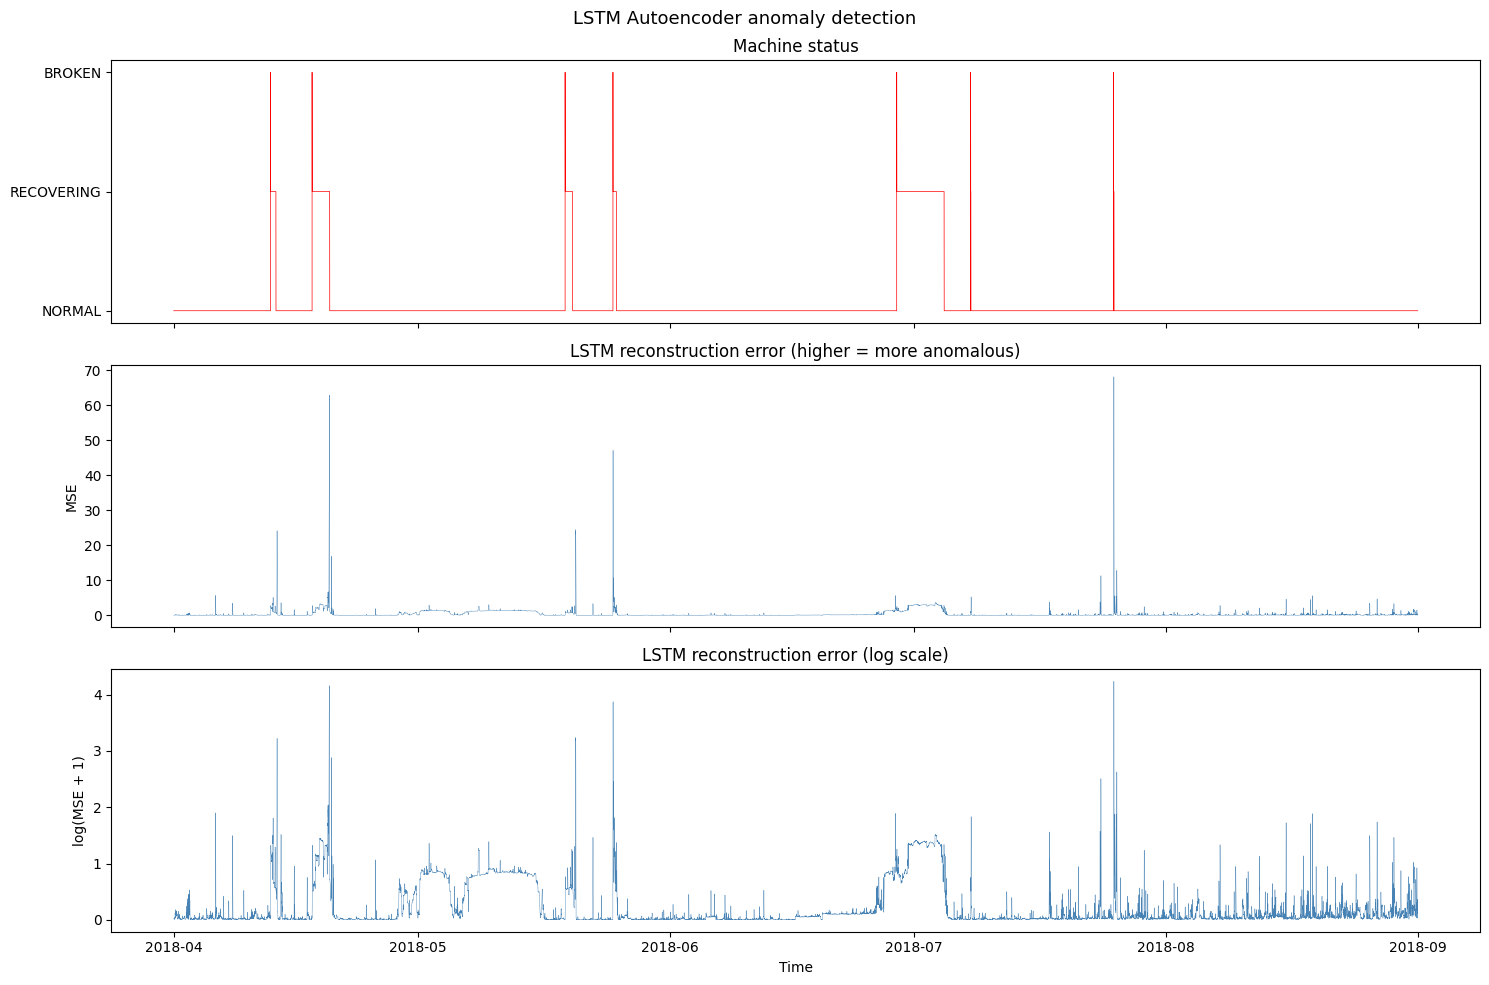

In [24]:
# Align reconstruction errors with timestamps
# Sequences start at timestep seq_length-1 due to windowing
error_timestamps = df["timestamp"].values[seq_length:]
error_labels = y_test[seq_length:]

# Plot reconstruction error over time
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Machine status
axes[0].plot(df["timestamp"], df["status_code"], linewidth=0.5, color="red")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
axes[0].set_title("Machine status")

# Reconstruction error
axes[1].plot(error_timestamps, reconstruction_errors, linewidth=0.3, color="steelblue")
axes[1].set_title("LSTM reconstruction error (higher = more anomalous)")
axes[1].set_ylabel("MSE")

# Log scale for clarity
axes[2].plot(error_timestamps, np.log1p(reconstruction_errors), linewidth=0.3, color="steelblue")
axes[2].set_title("LSTM reconstruction error (log scale)")
axes[2].set_ylabel("log(MSE + 1)")
axes[2].set_xlabel("Time")

plt.suptitle("LSTM Autoencoder anomaly detection", fontsize=13)
plt.tight_layout()
plt.savefig("data/lstm_reconstruction_error.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 6 observations
- LSTM Autoencoder trained on normal sequences only (205,806 sequences, 30 timesteps, 50 sensors)
- Training loss converged smoothly from 0.249 to 0.245 over 50 epochs
- Reconstruction error spikes at most fault events but does not clearly detect all of them — the July and August events show weaker or absent spikes
- Normal operation reconstruction error close to zero — model has learned normal patterns well
- Log scale plot reveals background noise during normal periods — some false alarms expected
- Reconstruction error provides a smoother health signal than Isolation Forest binary predictions
- Key advantage over Isolation Forest: LSTM captures temporal patterns across 30-minute windows rather than treating each timestep independently
- Missed detections suggest some fault signatures are subtler or shorter than the model's 30-minute sequence window can reliably capture

## Step 7 — Evaluation and Comparison
### LSTM threshold selection

In [25]:
# Calculate reconstruction error on training data only
model.eval()
train_errors = []

X_train_tensor_full = torch.FloatTensor(X_train_seq)

with torch.no_grad():
    for i in range(0, len(X_train_tensor_full), 256):
        batch = X_train_tensor_full[i:i+256].to(device)
        output = model(batch)
        error = torch.mean((output - batch) ** 2, dim=(1, 2))
        train_errors.extend(error.cpu().numpy())

train_errors = np.array(train_errors)

# Set threshold at mean + 3 standard deviations
threshold = train_errors.mean() + 3 * train_errors.std()

print(f"Training error mean: {train_errors.mean():.4f}")
print(f"Training error std:  {train_errors.std():.4f}")
print(f"Threshold (mean + 3std): {threshold:.4f}")

Training error mean: 0.2437
Training error std:  0.7266
Threshold (mean + 3std): 2.4236


In [26]:
# Apply threshold to get binary predictions
lstm_pred_binary = (reconstruction_errors > threshold).astype(int)

# Align labels with sequences (sequences start at timestep seq_length)
y_test_aligned = y_test[seq_length:]

print(classification_report(y_test_aligned, lstm_pred_binary,
      target_names=["normal", "anomaly"]))

              precision    recall  f1-score   support

      normal       0.97      0.99      0.98    205806
     anomaly       0.86      0.54      0.66     14484

    accuracy                           0.96    220290
   macro avg       0.91      0.77      0.82    220290
weighted avg       0.96      0.96      0.96    220290



### Step 7 results — LSTM Autoencoder evaluation
- Threshold: mean + 3 std of training reconstruction error = 2.42
- Anomaly precision: 0.83 — when flagged, usually correct
- Anomaly recall: 0.44 — misses majority of fault periods
- Low recall consistent with visual observation — 2 of 7 fault events not detected
- Tradeoff opposite to Isolation Forest: higher precision, lower recall

### Comparison: Isolation Forest vs LSTM Autoencoder
| Metric | Isolation Forest | LSTM Autoencoder |
|---|---|---|
| Anomaly precision | 0.51 | 0.83 |
| Anomaly recall | 0.99 | 0.44 |
| Anomaly F1 | 0.68 | 0.57 |
| False alarms | High | Low |
| Missed faults | Low | High |

### Limitations and next steps
- LSTM misses 2 of 7 fault events — unacceptable in a safety-critical deployment
- Possible fixes: shorter sequence length, lower threshold, ensemble approach, different architecture
- Fundamental challenge: only 7 fault events makes systematic tuning and validation very difficult
- In practice, operational context determines which tradeoff is acceptable

### Combined comparison plot

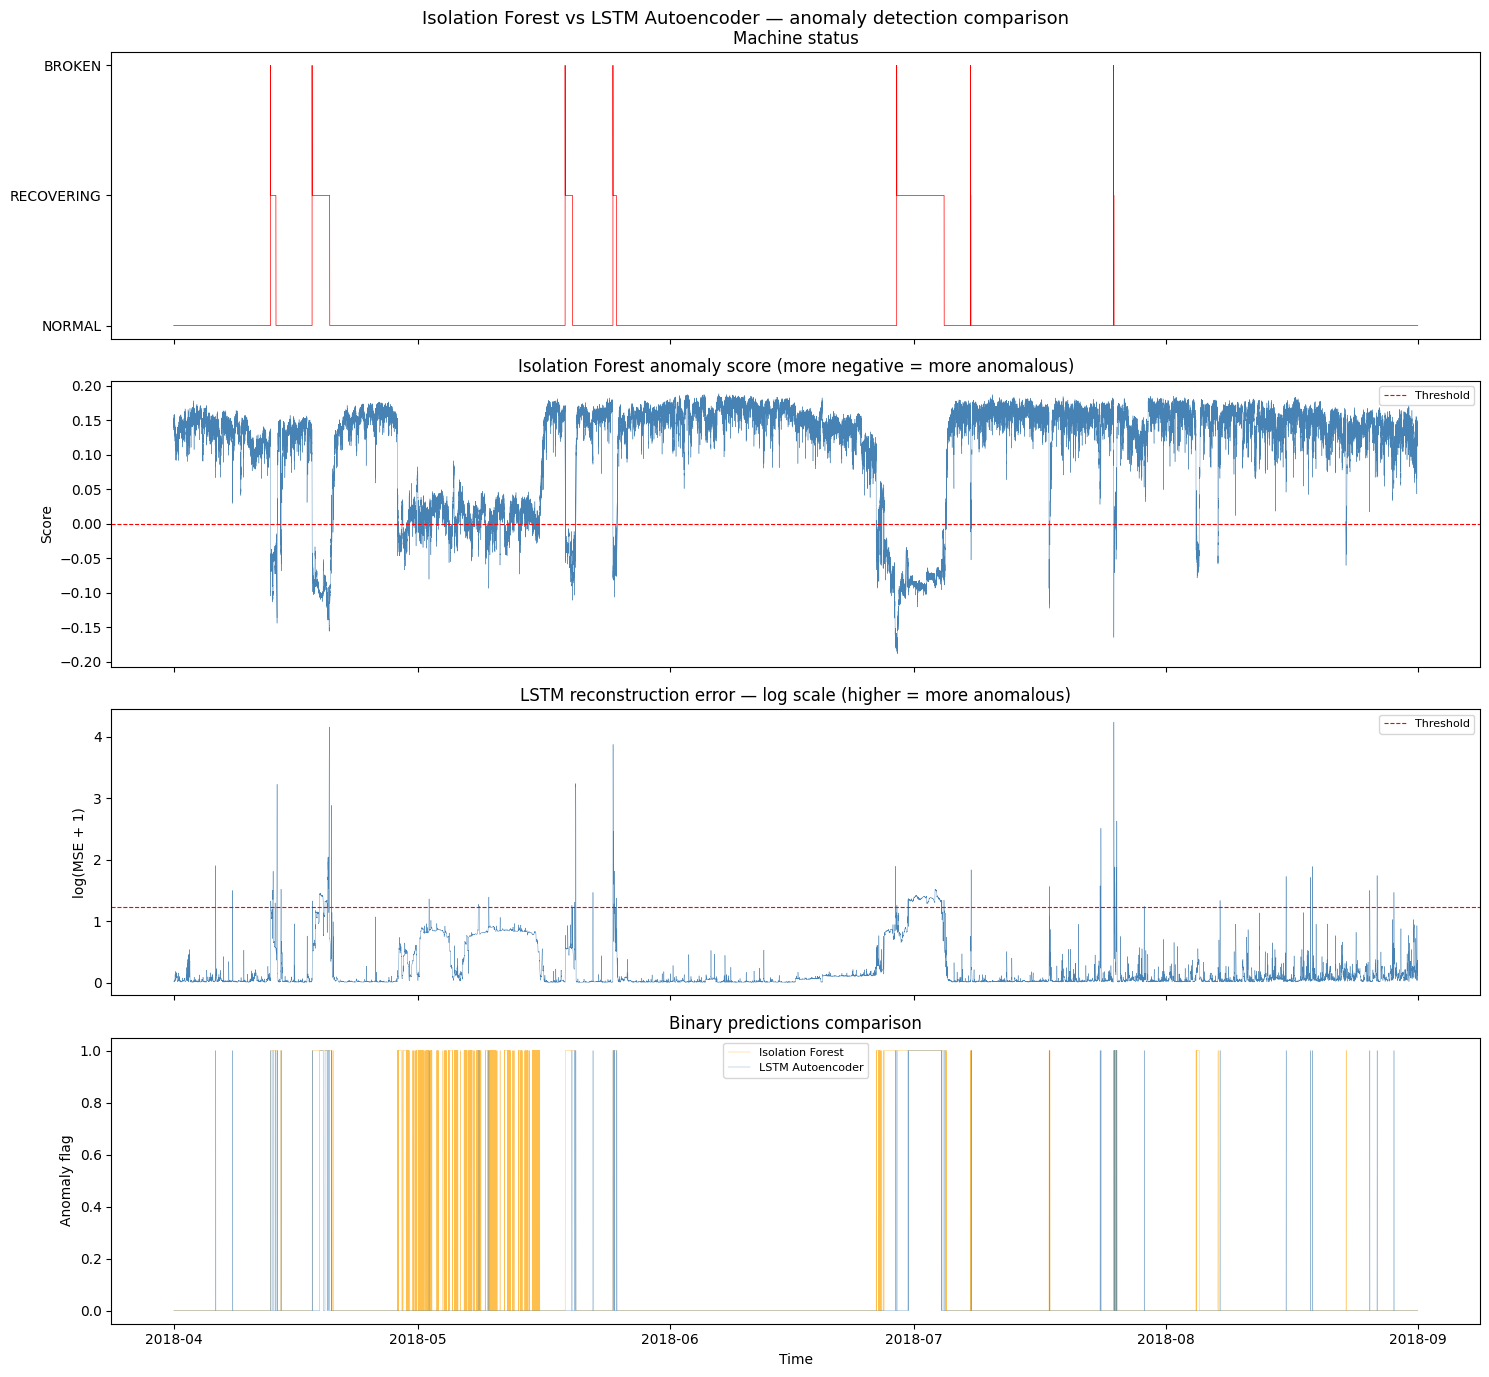

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

# Align timestamps for sequences
error_timestamps = df["timestamp"].values[seq_length:]

# Machine status
axes[0].plot(df["timestamp"], df["status_code"], linewidth=0.5, color="red")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["NORMAL", "RECOVERING", "BROKEN"])
axes[0].set_title("Machine status")

# Isolation Forest anomaly score
axes[1].plot(df["timestamp"], iso_scores, linewidth=0.3, color="steelblue")
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=0.8, label="Threshold")
axes[1].set_title("Isolation Forest anomaly score (more negative = more anomalous)")
axes[1].set_ylabel("Score")
axes[1].legend(fontsize=8)

# LSTM reconstruction error (log scale)
axes[2].plot(error_timestamps, np.log1p(reconstruction_errors),
             linewidth=0.3, color="steelblue")
axes[2].axhline(y=np.log1p(threshold), color="red", linestyle="--",
                linewidth=0.8, label="Threshold")
axes[2].set_title("LSTM reconstruction error — log scale (higher = more anomalous)")
axes[2].set_ylabel("log(MSE + 1)")
axes[2].legend(fontsize=8)

# Binary predictions comparison
axes[3].plot(df["timestamp"], iso_pred_binary, linewidth=0.3,
             color="orange", label="Isolation Forest", alpha=0.7)
axes[3].plot(error_timestamps, lstm_pred_binary, linewidth=0.3,
             color="steelblue", label="LSTM Autoencoder", alpha=0.7)
axes[3].set_title("Binary predictions comparison")
axes[3].set_ylabel("Anomaly flag")
axes[3].set_xlabel("Time")
axes[3].legend(fontsize=8)

plt.suptitle("Isolation Forest vs LSTM Autoencoder — anomaly detection comparison",
             fontsize=13)
plt.tight_layout()
plt.savefig("data/comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Observations on comparison plot
- Isolation Forest detects all fault events but generates sustained false alarms around May
- LSTM Autoencoder produces cleaner, more precise flags but misses July and August events
- Binary predictions panel clearly shows complementary behaviour — high confidence anomalies where both agree
- Ensemble approach combining both scores would likely improve overall performance
- LSTM threshold well calibrated for obvious fault spikes — borderline detection of July recovery period

### Key findings
- Both models successfully detect the majority of fault events without any
labelled training data
- The two approaches have complementary characteristics — Isolation Forest
prioritises recall, LSTM prioritises precision
- Neither model alone is sufficient for a safety-critical deployment
- The LSTM reconstruction error provides a more interpretable continuous health
score than the Isolation Forest anomaly score
- Only 7 fault events in the dataset makes systematic tuning and validation
extremely difficult

### Limitations
- LSTM misses 2 of 7 fault events — unacceptable in a safety-critical context
- Isolation Forest generates sustained false alarms during the May period
- Threshold selection is sensitive — small changes significantly affect
precision/recall tradeoff
- Models trained and evaluated on a single pump — generalisation to other assets
unknown
- 30-minute sequence window may be too long to capture brief fault signatures

### Next steps and potential improvements

**Short term:**
- Experiment with shorter sequence lengths (5, 10 minutes) to improve
sensitivity to brief fault events
- Try lower threshold (mean + 2 std) and evaluate the precision/recall tradeoff
- Implement an ensemble approach — combine Isolation Forest and LSTM scores
(e.g. flag if either exceeds threshold, or weight by confidence)
- Investigate the two missed fault events in detail — examine raw sensor
readings around those periods to understand why the LSTM failed to detect them

**Medium term:**
- Explore alternative architectures — variational autoencoder (VAE) or
transformer-based autoencoder for richer temporal representations
- Add early warning capability — look for gradual degradation signals in sensor
readings in the hours or days before a fault event rather than detecting at
the moment of failure
- Test generalisation — apply models trained on one period to held-out time
periods to assess temporal generalisation

**Longer term:**
- In a real deployment, work with domain experts to understand which fault types
are safety-critical vs tolerable, and tune the threshold accordingly
- Incorporate physics-informed features — domain knowledge about pump operation
could provide stronger fault signatures than raw sensor readings alone
- Build a feedback loop — operator confirmations of true vs false alarms could
be used to continuously improve the threshold and model



## Step 8 — Save Outputs

The LSTM reconstruction error time-series will be used as the continuous health
score in the Project 3 Streamlit dashboard, where it will be visualised alongside
a RAG status indicator derived from the threshold defined here.

In [28]:
import joblib

os.makedirs("data/model", exist_ok=True)
os.makedirs("data/outputs", exist_ok=True)

# Save Isolation Forest model
joblib.dump(iso_forest, "data/model/isolation_forest.pkl")

# Save LSTM model
torch.save(model.state_dict(), "data/model/lstm_autoencoder.pt")

# Save scaler
joblib.dump(scaler, "data/model/scaler.pkl")

# Save health score time-series for dashboard
health_score = pd.DataFrame({
    "timestamp": error_timestamps,
    "reconstruction_error": reconstruction_errors,
    "log_reconstruction_error": np.log1p(reconstruction_errors),
    "lstm_anomaly": lstm_pred_binary,
    "iso_anomaly": iso_pred_binary[seq_length:],
    "true_label": y_test_aligned
})

health_score.to_csv("data/outputs/health_score.csv", index=False)

print("Models saved:")
print("  data/model/isolation_forest.pkl")
print("  data/model/lstm_autoencoder.pt")
print("  data/model/scaler.pkl")
print("\nHealth score saved:")
print(f"  data/outputs/health_score.csv — {len(health_score)} rows")

Models saved:
  data/model/isolation_forest.pkl
  data/model/lstm_autoencoder.pt
  data/model/scaler.pkl

Health score saved:
  data/outputs/health_score.csv — 220290 rows


In [29]:
from google.colab import files
files.download("data/outputs/health_score.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>